In [50]:
from __future__ import annotations

import copy
import csv
import json
import os
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple
from loguru import logger
import torch
from torch import nn
from data.common import ProblemClass
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
# Your codebase imports (run from src/)
from pathlib import Path
from jobs.utils import build_dataloaders, set_all_seeds, device_from_args, pack_by_sizes
from jobs.finetune import eval_epoch
from metrics.optimization import get_optimal_solution, get_optimality_gap, kkt
from models.gnn import GNNPolicy
from models.mlp import KKTNetMLP
import configargparse

In [51]:
out_dir = Path("./results/budget_sweep")
out_dir.mkdir(parents=True, exist_ok=True)
parser = configargparse.ArgumentParser(
    allow_abbrev=False,
    default_config_files=["../configs/finetune/milp/CA/finetune_CA_200/finetune_CA_200_gnn_full_finetune.yml"],
)
parser.add_argument(
        "--encoder_path",
        type=str,
        help="Path to encoder-only checkpoint from pretraining (e.g., .../best_encoder.pt).",
    )
parser.add_argument("--devices", type=str, default="0")
parser.add_argument("--batch_size", type=int, default=8)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
        "--finetune_mode",
        type=str,
        choices=["full", "heads"],
        default="full",
        help="'full' updates encoder+heads; 'heads' freezes encoder and trains heads only.",
    )

d = parser.add_argument_group("data")

d.add_argument(
    "--use_bipartite_graphs", action="store_true", help="Must be set for GNNPolicy."
)
d.add_argument(
    "--problems",
    type=str,
    nargs="+",
    default=[ProblemClass.COMBINATORIAL_AUCTION],
    help="Problem type(s).",
)
d.add_argument(
    "--is_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--ca_sizes", type=int, nargs="+", default=[100]
)
d.add_argument(
    "--sc_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--cfl_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--rnd_sizes", type=int, nargs="+", default=[200]
)

d.add_argument("--n_instances", type=int, default=35000)
d.add_argument("--data_root", type=str, default="../data/instances")
d.add_argument(
    "--val_split",
    type=float,
    default=0.15,
    help="Validation split ratio (default: 0.15 for 70/15/15 train/val/test)",
)
args, _ = parser.parse_known_args()
GNNPolicy.add_args(parser)
# Add MLP-specific args directly (KKTNetMLP.add_args would duplicate LeJepaEncoderModule args)
mlp_group = parser.add_argument_group("mlp")
mlp_group.add_argument("--hidden", type=int, default=256)
mlp_group.add_argument("--embed_dim", type=int, default=128)

args, _ = parser.parse_known_args()

# --- Problem families and their ProblemClass mappings ---
FAMILIES = ["IS", "CA", "SC", "CFL"]
FAMILY_TO_PROBLEM = {
    "IS": ProblemClass.INDEPENDANT_SET,
    "CA": ProblemClass.COMBINATORIAL_AUCTION,
    "SC": ProblemClass.SET_COVER,
    "CFL": ProblemClass.CAPACITATED_FACILITY_LOCATION,
}

In [52]:
print("Arguments:", args)

Arguments: Namespace(encoder_path='/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/gnn_pretraining/run_gnn_policy-gv=2-lv=8-slice=512-point=13-lmbd=0.256-std=0.0-dim=128-l_mask=0.6-g_mask=0.05-l_e_mask=0.05-g_e_mask=0.6-dp=0.05-l_dim=128-conv=gatv2-heads=4_20260406_145138/best_encoder.pt', devices='0', batch_size=80, num_workers=0, seed=42, finetune_mode='full', use_bipartite_graphs=True, problems=['CA'], is_sizes=[200], ca_sizes=[100], sc_sizes=[200], cfl_sizes=[200], rnd_sizes=[200], n_instances=50000, data_root='./data/instances/milp/finetune', val_split=0.15, lejepa_n_global_views=2, lejepa_n_local_views=8, sigreg_slices=512, sigreg_points=13, lejepa_lambda=0.256, lejepa_std_loss_weight=0.0, embedding_size=128, cons_nfeats=9, edge_nfeats=1, var_nfeats=18, num_emb_type='periodic', num_emb_bins=32, num_emb_freqs=16, lejepa_local_mask=0.6, lejepa_global_mask=0.05, lejepa_local_edge_mask=0.05, lejepa_global_edge_mask=0.6, dropout=0.05, lejepa_embed_dim=128, bipartite_conv='gatv

In [53]:
set_all_seeds(args.seed)
device = device_from_args(args)

In [54]:
# Resolve data_root to absolute path (notebook runs from src/notebooks/)
args.data_root = str(Path("../data/instances").resolve())
print(f"Using data root: {args.data_root}")

Using data root: /home/joachim-verschelde/Repos/KKT_MPNN/src/data/instances


In [55]:
def _get_state_dict(pkg):
    if isinstance(pkg, dict):
        if "model" in pkg:
            return pkg["model"]
        if "state_dict" in pkg:
            return pkg["state_dict"]
    return pkg  # assume raw state_dict

def _is_mlp_checkpoint(sd: dict) -> bool:
    """Detect whether a state_dict belongs to an MLP model (has trunk keys)."""
    return any("trunk" in k for k in sd)

def infer_MN_from_ckpt(ckpt_path: Path):
    pkg = torch.load(ckpt_path, map_location="cpu")
    sd = _get_state_dict(pkg)

    if not _is_mlp_checkpoint(sd):
        return None, None

    Din = sd["encoder.trunk.0.weight"].shape[1]
    M = sd["head_lam.2.bias"].shape[0]
    N = sd["head_x.2.bias"].shape[0]

    expected = M * N + M + N
    if Din != expected:
        raise ValueError(f"Inconsistent dims: Din={Din}, but M*N+M+N={expected} (M={M}, N={N})")
    print(f"MLP checkpoint: M={M} N={N}")
    return M, N

In [56]:
experiment_root = Path("/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments")
sizes = [10, 50, 200]
strategies = ["gnn_baseline", "mlp_baseline", "gnn_frozen_encoder", "gnn_full_finetune"]
checkpoint_steps = [500, 1000, 2000, 5000, 20000]

# Map strategy dir names to short scenario names used in tables/plots
STRATEGY_TO_SCENARIO = {
    "gnn_baseline": "gnn",
    "mlp_baseline": "mlp",
    "gnn_frozen_encoder": "gnnfe",
    "gnn_full_finetune": "gnnff",
}

out_csv = experiment_root / "exp1_budget_sweep_results_all_families.csv"

# Cache dataloaders per (family, size, use_bipartite)
dl_cache: Dict[Tuple[str, int, bool], Tuple] = {}

rows: List[Dict[str, object]] = []

for size in tqdm(sizes, desc="sizes"):
    for family in tqdm(FAMILIES, desc="families", leave=False):
        for strategy in tqdm(strategies, desc="strategies", leave=False):
            scenario = STRATEGY_TO_SCENARIO[strategy]

            # Locate the run directory
            strategy_dir = (
                experiment_root
                / "gnn_finetuning"
                / f"finetune_{family}_{size}"
                / f"finetune_{family}_{size}_{strategy}"
                / "gnn_finetuning"
            )
            if not strategy_dir.exists():
                print(f"SKIP (dir missing): {family} {size} {strategy}")
                continue

            run_dirs = sorted(strategy_dir.glob("run_*"))
            if not run_dirs:
                print(f"SKIP (no runs): {family} {size} {strategy}")
                continue
            # Take the latest run directory
            model_dir = run_dirs[-1]

            # Build checkpoint paths: step 20000 -> last.pt
            checkpoint_paths = {}
            for step in checkpoint_steps:
                if step == 20000:
                    checkpoint_paths[step] = model_dir / "last.pt"
                else:
                    checkpoint_paths[step] = model_dir / f"step_{step:06d}.pt"

            # Configure data for this family
            args.problems = [FAMILY_TO_PROBLEM[family]]
            args.is_sizes = [size]
            args.ca_sizes = [size // 2]  # CA always uses half
            args.sc_sizes = [size]
            args.cfl_sizes = [size]

            # Detect actual model type from checkpoint (mlp_baseline dir may contain GNN)
            first_existing_ckpt = next(
                (checkpoint_paths[s] for s in checkpoint_steps if checkpoint_paths[s].exists()),
                None,
            )
            if first_existing_ckpt is None:
                print(f"SKIP (no checkpoints): {family} {size} {strategy}")
                continue

            M_fixed, N_fixed = infer_MN_from_ckpt(first_existing_ckpt)
            is_actually_mlp = M_fixed is not None
            use_bipartite = not is_actually_mlp
            args.use_bipartite_graphs = use_bipartite

            # Get or build dataloaders
            cache_key = (family, size, use_bipartite)
            if cache_key not in dl_cache:
                train_loader, valid_loader, test_loader, N_max, M_max = build_dataloaders(
                    args, M_max=M_fixed, N_max=N_fixed, for_pretraining=False
                )
                dl_cache[cache_key] = (train_loader, valid_loader, test_loader, N_max, M_max)
            else:
                train_loader, valid_loader, test_loader, N_max, M_max = dl_cache[cache_key]

            # Build model
            model = (
                KKTNetMLP(args, M_fixed, N_fixed).to(device)
                if is_actually_mlp
                else GNNPolicy(args).to(device)
            )

            for step in tqdm(checkpoint_steps, desc="steps", leave=False):
                ckpt_path = checkpoint_paths[step]
                if not ckpt_path.exists():
                    print(f"  SKIP (missing): {ckpt_path.name}")
                    continue
                try:
                    pkg = torch.load(ckpt_path, map_location="cpu")
                    sd = _get_state_dict(pkg)
                    model.load_state_dict(sd, strict=True)
                    model = model.to(device)

                    metrics = eval_epoch(model, test_loader, device, 0.1, 0.1, 0.6, 0.2)

                    rows.append({
                        "size": size,
                        "family": family,
                        "scenario": scenario,
                        "run_dir": model_dir.name,
                        "step": step,
                        "ckpt_path": str(ckpt_path),
                        **metrics,
                    })
                except Exception as e:
                    print(f"  ERROR: {family} {size} {strategy} step={step} | {e}")
                    continue

print(f"Collected {len(rows)} results")

sizes:   0%|          | 0/3 [00:00<?, ?it/s]

families:   0%|          | 0/4 [00:00<?, ?it/s]

strategies:   0%|          | 0/4 [00:00<?, ?it/s]

args Namespace(encoder_path='/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/gnn_pretraining/run_gnn_policy-gv=2-lv=8-slice=512-point=13-lmbd=0.256-std=0.0-dim=128-l_mask=0.6-g_mask=0.05-l_e_mask=0.05-g_e_mask=0.6-dp=0.05-l_dim=128-conv=gatv2-heads=4_20260406_145138/best_encoder.pt', devices='0', batch_size=80, num_workers=0, seed=42, finetune_mode='full', use_bipartite_graphs=True, problems=['IS'], is_sizes=[10], ca_sizes=[5], sc_sizes=[10], cfl_sizes=[10], rnd_sizes=[200], n_instances=50000, data_root='/home/joachim-verschelde/Repos/KKT_MPNN/src/data/instances', val_split=0.15, lejepa_n_global_views=2, lejepa_n_local_views=8, sigreg_slices=512, sigreg_points=13, lejepa_lambda=0.256, lejepa_std_loss_weight=0.0, embedding_size=128, cons_nfeats=9, edge_nfeats=1, var_nfeats=18, num_emb_type='periodic', num_emb_bins=32, num_emb_freqs=16, lejepa_local_mask=0.6, lejepa_global_mask=0.05, lejepa_local_edge_mask=0.05, lejepa_global_edge_mask=0.6, dropout=0.05, lejepa_embed_dim=128, bip

steps:   0%|          | 0/5 [00:00<?, ?it/s]

...

steps:   0%|          | 0/5 [00:00<?, ?it/s]

steps:   0%|          | 0/5 [00:00<?, ?it/s]

steps:   0%|          | 0/5 [00:00<?, ?it/s]

steps:   0%|          | 0/5 [00:00<?, ?it/s]

Collected 240 results


In [88]:
import pandas as pd
rows_df = pd.DataFrame(rows)
print(f"{len(rows_df)} rows, families: {rows_df['family'].unique()}")
rows_df.head()

240 rows, families: ['IS' 'CA' 'SC' 'CFL']


,size,family,scenario,run_dir,step,ckpt_path,valid/kkt_loss,valid/kkt_loss_std,valid/primal_feasibility,valid/primal_feasibility_std,valid/dual_feasibility,valid/dual_feasibility_std,valid/stationarity,valid/stationarity_std,valid/complementary_slackness,valid/complementary_slackness_std,valid/duality_gap,valid/duality_gap_std,valid/objective_gap,valid/objective_gap_std
0,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,500,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.426681,0.064911,0.005572,0.002950,0.0,0.0,0.420985,0.064663,0.000124,0.000047,1.326727,0.195306,0.113814,0.089534
1,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,1000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.119226,0.025113,0.001511,0.007414,0.0,0.0,0.117070,0.028082,0.000645,0.001147,0.287624,0.092541,0.132309,0.147069
2,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,2000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.060899,0.069554,0.000442,0.000509,0.0,0.0,0.058668,0.068770,0.001789,0.000981,0.363130,0.186096,0.230923,0.072372
3,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,5000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.385663,0.235324,0.002628,0.002284,0.0,0.0,0.380414,0.236893,0.002621,0.000672,0.556195,0.316620,0.136577,0.095288
4,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,20000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.049860,0.045132,0.006861,0.026706,0.0,0.0,0.041526,0.017816,0.001473,0.004999,0.266015,0.086332,0.190430,0.273621


In [89]:
len(rows_df)

240

In [90]:
rows_df.head()

,size,family,scenario,run_dir,step,ckpt_path,valid/kkt_loss,valid/kkt_loss_std,valid/primal_feasibility,valid/primal_feasibility_std,valid/dual_feasibility,valid/dual_feasibility_std,valid/stationarity,valid/stationarity_std,valid/complementary_slackness,valid/complementary_slackness_std,valid/duality_gap,valid/duality_gap_std,valid/objective_gap,valid/objective_gap_std
0,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,500,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.426681,0.064911,0.005572,0.002950,0.0,0.0,0.420985,0.064663,0.000124,0.000047,1.326727,0.195306,0.113814,0.089534
1,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,1000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.119226,0.025113,0.001511,0.007414,0.0,0.0,0.117070,0.028082,0.000645,0.001147,0.287624,0.092541,0.132309,0.147069
2,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,2000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.060899,0.069554,0.000442,0.000509,0.0,0.0,0.058668,0.068770,0.001789,0.000981,0.363130,0.186096,0.230923,0.072372
3,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,5000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.385663,0.235324,0.002628,0.002284,0.0,0.0,0.380414,0.236893,0.002621,0.000672,0.556195,0.316620,0.136577,0.095288
4,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,20000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.049860,0.045132,0.006861,0.026706,0.0,0.0,0.041526,0.017816,0.001473,0.004999,0.266015,0.086332,0.190430,0.273621


In [76]:
rows_df.to_csv(out_csv, index=False)
print(f"Saved to {out_csv}")

Saved to /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/exp1_budget_sweep_results_all_families.csv


In [77]:
rows_df.head()

,size,family,scenario,run_dir,step,ckpt_path,valid/kkt_loss,valid/kkt_loss_std,valid/primal_feasibility,valid/primal_feasibility_std,valid/dual_feasibility,valid/dual_feasibility_std,valid/stationarity,valid/stationarity_std,valid/complementary_slackness,valid/complementary_slackness_std,valid/duality_gap,valid/duality_gap_std,valid/objective_gap,valid/objective_gap_std
1,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,1000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.119226,0.025113,0.001511,0.007414,0.0,0.0,0.117070,0.028082,0.000645,0.001147,0.287624,0.092541,0.132309,0.147069
2,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,2000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.060899,0.069554,0.000442,0.000509,0.0,0.0,0.058668,0.068770,0.001789,0.000981,0.363130,0.186096,0.230923,0.072372
3,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,5000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.385663,0.235324,0.002628,0.002284,0.0,0.0,0.380414,0.236893,0.002621,0.000672,0.556195,0.316620,0.136577,0.095288
4,10,IS,gnn,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,20000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.049860,0.045132,0.006861,0.026706,0.0,0.0,0.041526,0.017816,0.001473,0.004999,0.266015,0.086332,0.190430,0.273621
6,10,IS,mlp,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,1000,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,0.135218,0.043179,0.006439,0.002741,0.0,0.0,0.128037,0.040939,0.000742,0.000309,0.749048,0.154712,0.262094,0.114129


In [78]:
# Average metrics across all problem families per (scenario, size, step)
metric_cols = [c for c in rows_df.columns if c.startswith("valid/")]
group_cols = ["scenario", "size", "step", "run_dir"]

# First, average across families within each run/step
rows_avg_df = (
    rows_df
    .groupby(group_cols, as_index=False)[metric_cols]
    .mean()
)
# Add a "dataset" column for compatibility with the pivot/plot functions
rows_avg_df["dataset"] = "all_families"
print(f"Aggregated to {len(rows_avg_df)} rows (averaged across {len(FAMILIES)} families)")
rows_avg_df.head()

Aggregated to 142 rows (averaged across 4 families)


,scenario,size,step,run_dir,valid/kkt_loss,valid/kkt_loss_std,valid/primal_feasibility,valid/primal_feasibility_std,valid/dual_feasibility,valid/dual_feasibility_std,valid/stationarity,valid/stationarity_std,valid/complementary_slackness,valid/complementary_slackness_std,valid/duality_gap,valid/duality_gap_std,valid/objective_gap,valid/objective_gap_std,dataset
0,gnn,10,500,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,3322.781292,2807.506638,0.012139,0.010071,0.0,0.0,3276.356574,2802.442685,46.412585,28.160795,0.415347,0.227529,0.167540,0.128606,all_families
1,gnn,10,500,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,3756.761006,777.040089,0.142467,0.016750,0.0,0.0,3753.528562,777.339188,3.089998,0.534449,0.838216,0.170188,0.652022,0.652084,all_families
2,gnn,10,1000,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,2370.214535,1823.453090,0.000535,0.001537,0.0,0.0,2314.211945,1827.786379,56.002065,27.935187,0.243351,0.185949,0.290893,0.144983,all_families
3,gnn,10,1000,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,271336.276667,91762.954203,186.152964,78.402046,0.0,0.0,243125.600083,80740.931768,28024.521068,14521.566387,0.843205,0.222947,0.134674,0.094834,all_families
4,gnn,10,1000,run_gnn_policy-gv=2-lv=8-slice=512-point=13-lm...,0.119226,0.025113,0.001511,0.007414,0.0,0.0,0.117070,0.028082,0.000645,0.001147,0.287624,0.092541,0.132309,0.147069,all_families


In [79]:
rows_avg_df.columns

Index(['scenario', 'size', 'step', 'run_dir', 'valid/kkt_loss',
       'valid/kkt_loss_std', 'valid/primal_feasibility',
       'valid/primal_feasibility_std', 'valid/dual_feasibility',
       'valid/dual_feasibility_std', 'valid/stationarity',
       'valid/stationarity_std', 'valid/complementary_slackness',
       'valid/complementary_slackness_std', 'valid/duality_gap',
       'valid/duality_gap_std', 'valid/objective_gap',
       'valid/objective_gap_std', 'dataset'],
      dtype='object')

In [80]:
import numpy as np
import pandas as pd

# Step budgets used in the paper tables
STEPS = [500, 1000, 2000, 5000, 20000]

# Row order used in the LaTeX tables
METHOD_ORDER = ["MLP-BL", "GNN-BL", "GNN-FE", "GNN-FF"]


SCENARIO_TO_METHOD = {
    "mlp": "MLP-BL",
    "gnn": "GNN-BL",
    "gnnfe": "GNN-FE",
    "gnnff": "GNN-FF",
}


def budget_sweep_pivot_with_std(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/duality_gap",
    metric_std: str | None = None,
    multiply_by_100: bool = True,
    std_ddof: int = 0,
    cell_fmt: str = "{:.2f}",
    pm_latex: bool = True,
) -> pd.DataFrame:
    """
    Returns a (Method x Step) table of strings "mean \\pm std" aggregated across runs.
    """
    d = df.copy()

    d = d[d["step"].isin(STEPS)]
    d = d[d["size"] == size]
    if dataset is not None:
        d = d[d["dataset"] == dataset]

    d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])

    if metric not in d.columns:
        raise KeyError(
            f"Metric column '{metric}' not found. Available columns: {list(d.columns)}"
        )

    has_logged_std = metric_std is not None and metric_std in d.columns

    group_cols = ["size", "dataset", "Method", "run_dir", "step"]
    agg_dict = {metric: "mean"}
    if has_logged_std:
        agg_dict[metric_std] = "mean"

    d1 = d.groupby(group_cols, as_index=False).agg(agg_dict)

    if multiply_by_100:
        d1[metric] = 100.0 * d1[metric]
        if has_logged_std:
            d1[metric_std] = 100.0 * d1[metric_std]

    gcols2 = ["size", "dataset", "Method", "step"]

    if has_logged_std:
        d2 = d1.groupby(gcols2, as_index=False)[metric].mean().rename(columns={metric: "mean"})
        d2_std = d1.groupby(gcols2, as_index=False)[metric_std].mean().rename(columns={metric_std: "std"})
        d2 = d2.merge(d2_std, on=gcols2, how="left")
    else:
        d2 = (
            d1.groupby(gcols2, as_index=False)[metric]
              .agg(mean="mean", std=lambda x: float(np.std(x, ddof=std_ddof)))
        )

    pm = r"\pm" if pm_latex else "±"

    def format_cell(mu: float, sd: float) -> str:
        if pd.isna(mu):
            return np.nan
        sd = 0.0 if pd.isna(sd) else float(sd)
        return f"{cell_fmt.format(float(mu))} {pm} {cell_fmt.format(sd)}"

    d2["cell"] = [format_cell(mu, sd) for mu, sd in zip(d2["mean"], d2["std"])]

    pivot = d2.pivot_table(index="Method", columns="step", values="cell", aggfunc="first")
    pivot = pivot.reindex(METHOD_ORDER)
    pivot = pivot.reindex(columns=STEPS)

    return pivot


def pivot_to_latex_table_booktabs(
    pivot: pd.DataFrame,
    *,
    caption: str,
    label: str,
    steps: list[int],
    missing_cell: str = r"--",
    span_two_columns: bool = True,
    scale: str | None = r"\textwidth",
    font_cmd: str = r"\small",
    tabcolsep_pt: int | None = 3,
) -> str:
    header = ["Method"] + [f"{s//1000}k" if s >= 1000 else str(s) for s in steps]

    env = "table*" if span_two_columns else "table"

    lines = []
    lines.append(fr"\begin{{{env}}}[t]")
    lines.append(r"\caption{" + caption + r"}")
    lines.append(r"\label{" + label + r"}")
    lines.append(r"\centering")
    lines.append(font_cmd)
    if tabcolsep_pt is not None:
        lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")

    if scale is not None:
        lines.append(rf"\resizebox{{{scale}}}{{!}}{{%")

    lines.append(r"\begin{tabular}{l" + "c"*len(steps) + "}")
    lines.append(r"\toprule")
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\midrule")

    for method in METHOD_ORDER:
        row = [method]
        for s in steps:
            x = pivot.loc[method, s] if (method in pivot.index and s in pivot.columns) else np.nan
            if pd.isna(x):
                row.append(missing_cell)
            else:
                if isinstance(x, str) and r"\pm" in x:
                    mu_str, sd_str = x.split(r"\pm")
                    mu = float(mu_str.strip())
                    sd = float(sd_str.strip())
                    row.append(rf"\({mu:.1f} \pm {sd:.1f}\)")
                else:
                    row.append(rf"\({float(x):.1f}\)")
        lines.append(" & ".join(row) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    if scale is not None:
        lines.append(r"}")

    lines.append(fr"\end{{{env}}}")
    return "\n".join(lines)



In [81]:

# -------------------------
# Build tables from averaged results
# -------------------------

DATASET_FILTER = "all_families"

t10  = budget_sweep_pivot_with_std(rows_avg_df, 10,  dataset=DATASET_FILTER, metric="valid/duality_gap", metric_std="valid/duality_gap_std")
t50  = budget_sweep_pivot_with_std(rows_avg_df, 50,  dataset=DATASET_FILTER, metric="valid/duality_gap", metric_std="valid/duality_gap_std")
t200 = budget_sweep_pivot_with_std(rows_avg_df, 200, dataset=DATASET_FILTER, metric="valid/duality_gap", metric_std="valid/duality_gap_std")

display(t10)
display(t50)
display(t200)

# Emit LaTeX
latex10 = pivot_to_latex_table_booktabs(
    t10,
    caption=r"Avg. validation relative duality gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=10$. Lower is better.",
    label="tab:budget_sweep_n10",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)
latex50 = pivot_to_latex_table_booktabs(
    t50,
    caption=r"Avg. validation relative duality gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=50$. Lower is better.",
    label="tab:budget_sweep_n50",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)
latex200 = pivot_to_latex_table_booktabs(
    t200,
    caption=r"Avg. validation relative duality gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=200$. Lower is better.",
    label="tab:budget_sweep_n200",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)

print(latex10)
print()
print(latex50)
print()
print(latex200)

step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,42.08 \pm 23.17,48.99 \pm 16.30,59.23 \pm 25.40,54.07 \pm 24.48,50.87 \pm 31.41
GNN-BL,62.68 \pm 19.89,45.81 \pm 16.71,47.94 \pm 21.27,58.50 \pm 40.45,39.82 \pm 24.02
GNN-FE,95.73 \pm 16.75,51.99 \pm 19.21,49.96 \pm 34.19,60.08 \pm 39.59,58.34 \pm 38.28
GNN-FF,69.10 \pm 15.97,65.41 \pm 31.44,73.70 \pm 38.82,55.68 \pm 37.21,56.87 \pm 36.35


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,16.97 \pm 12.73,68.22 \pm 15.20,55.86 \pm 12.03,17.08 \pm 12.43,61.48 \pm 17.45
GNN-BL,18.88 \pm 14.07,65.42 \pm 13.06,74.51 \pm 17.49,35.09 \pm 12.95,57.87 \pm 25.23
GNN-FE,37.54 \pm 13.34,46.21 \pm 19.76,26.87 \pm 19.57,60.59 \pm 33.84,35.51 \pm 24.89
GNN-FF,59.54 \pm 19.68,59.11 \pm 22.82,70.02 \pm 32.91,41.09 \pm 25.37,38.80 \pm 18.65


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,14.18 \pm 9.21,32.90 \pm 11.34,57.66 \pm 24.23,NaN,44.19 \pm 10.51
GNN-BL,11.26 \pm 8.00,47.77 \pm 29.85,69.91 \pm 12.72,11.63 \pm 7.43,60.69 \pm 6.68
GNN-FE,81.83 \pm 25.66,80.30 \pm 7.34,54.95 \pm 19.36,74.27 \pm 10.42,79.26 \pm 11.29
GNN-FF,91.97 \pm 2.00,47.30 \pm 10.06,58.97 \pm 9.53,25.97 \pm 22.60,43.40 \pm 18.89


\begin{table}[t]
\caption{Avg. validation relative duality gap (\%) across IS/CA/SC/CFL after $S$ fine-tuning steps for $n=10$. Lower is better.}
\label{tab:budget_sweep_n10}
\centering
\footnotesize
\setlength{\tabcolsep}{3pt}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{lccccc}
\toprule
Method & 500 & 1k & 2k & 5k & 20k \\
\midrule
MLP-BL & \(42.1 \pm 23.2\) & \(49.0 \pm 16.3\) & \(59.2 \pm 25.4\) & \(54.1 \pm 24.5\) & \(50.9 \pm 31.4\) \\
GNN-BL & \(62.7 \pm 19.9\) & \(45.8 \pm 16.7\) & \(47.9 \pm 21.3\) & \(58.5 \pm 40.5\) & \(39.8 \pm 24.0\) \\
GNN-FE & \(95.7 \pm 16.8\) & \(52.0 \pm 19.2\) & \(50.0 \pm 34.2\) & \(60.1 \pm 39.6\) & \(58.3 \pm 38.3\) \\
GNN-FF & \(69.1 \pm 16.0\) & \(65.4 \pm 31.4\) & \(73.7 \pm 38.8\) & \(55.7 \pm 37.2\) & \(56.9 \pm 36.4\) \\
\bottomrule
\end{tabular}
}
\end{table}

\begin{table}[t]
\caption{Avg. validation relative duality gap (\%) across IS/CA/SC/CFL after $S$ fine-tuning steps for $n=50$. Lower is better.}
\label{tab:budget_sweep_n50}
\center

In [82]:

# -------------------------
# Build tables from averaged results
# -------------------------

DATASET_FILTER = "all_families"

t10  = budget_sweep_pivot_with_std(rows_avg_df, 10,  dataset=DATASET_FILTER, metric="valid/objective_gap", metric_std="valid/objective_gap_std")
t50  = budget_sweep_pivot_with_std(rows_avg_df, 50,  dataset=DATASET_FILTER, metric="valid/objective_gap", metric_std="valid/objective_gap_std")
t200 = budget_sweep_pivot_with_std(rows_avg_df, 200, dataset=DATASET_FILTER, metric="valid/objective_gap", metric_std="valid/objective_gap_std")

display(t10)
display(t50)
display(t200)

# Emit LaTeX
latex10 = pivot_to_latex_table_booktabs(
    t10,
    caption=r"Avg. validation relative objective gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=10$. Lower is better.",
    label="tab:budget_sweep_n10",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)
latex50 = pivot_to_latex_table_booktabs(
    t50,
    caption=r"Avg. validation relative objective gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=50$. Lower is better.",
    label="tab:budget_sweep_n50",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)
latex200 = pivot_to_latex_table_booktabs(
    t200,
    caption=r"Avg. validation relative objective gap (\%) across IS/CA/SC/CFL "
        r"after $S$ fine-tuning steps for $n=200$. Lower is better.",
    label="tab:budget_sweep_n200",
    steps=STEPS,
    span_two_columns=False,
    scale=r"\columnwidth",
    font_cmd=r"\footnotesize",
    tabcolsep_pt=3,
)

print(latex10)
print()
print(latex50)
print()
print(latex200)

step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,16.84 \pm 12.06,23.80 \pm 12.52,25.87 \pm 13.21,25.78 \pm 23.24,27.30 \pm 21.90
GNN-BL,40.98 \pm 39.03,18.60 \pm 12.90,21.18 \pm 7.59,26.35 \pm 16.70,35.27 \pm 23.41
GNN-FE,39.73 \pm 11.29,29.05 \pm 12.35,15.92 \pm 8.27,36.35 \pm 36.54,59.60 \pm 40.71
GNN-FF,15.54 \pm 9.75,48.60 \pm 16.39,44.68 \pm 24.15,38.11 \pm 27.36,37.34 \pm 41.76


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,17.37 \pm 14.31,28.90 \pm 8.04,26.64 \pm 6.64,36.83 \pm 10.09,54.19 \pm 16.91
GNN-BL,16.29 \pm 12.06,32.31 \pm 8.09,37.34 \pm 7.69,17.11 \pm 9.19,53.26 \pm 20.55
GNN-FE,26.44 \pm 7.31,26.80 \pm 13.07,19.61 \pm 14.08,32.26 \pm 9.75,34.47 \pm 9.89
GNN-FF,34.81 \pm 12.46,39.92 \pm 12.90,73.90 \pm 23.23,46.86 \pm 12.54,21.16 \pm 10.01


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,8.48 \pm 6.68,52.99 \pm 5.02,43.72 \pm 4.68,NaN,92.71 \pm 16.54
GNN-BL,15.82 \pm 10.73,10.90 \pm 7.40,40.66 \pm 3.38,20.10 \pm 11.15,71.44 \pm 13.60
GNN-FE,64.53 \pm 9.53,31.73 \pm 3.80,35.45 \pm 6.53,53.92 \pm 12.04,56.61 \pm 14.17
GNN-FF,12.29 \pm 1.24,67.67 \pm 13.94,25.08 \pm 9.84,51.86 \pm 6.07,39.62 \pm 4.70


\begin{table}[t]
\caption{Avg. validation relative objective gap (\%) across IS/CA/SC/CFL after $S$ fine-tuning steps for $n=10$. Lower is better.}
\label{tab:budget_sweep_n10}
\centering
\footnotesize
\setlength{\tabcolsep}{3pt}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{lccccc}
\toprule
Method & 500 & 1k & 2k & 5k & 20k \\
\midrule
MLP-BL & \(16.8 \pm 12.1\) & \(23.8 \pm 12.5\) & \(25.9 \pm 13.2\) & \(25.8 \pm 23.2\) & \(27.3 \pm 21.9\) \\
GNN-BL & \(41.0 \pm 39.0\) & \(18.6 \pm 12.9\) & \(21.2 \pm 7.6\) & \(26.4 \pm 16.7\) & \(35.3 \pm 23.4\) \\
GNN-FE & \(39.7 \pm 11.3\) & \(29.1 \pm 12.3\) & \(15.9 \pm 8.3\) & \(36.4 \pm 36.5\) & \(59.6 \pm 40.7\) \\
GNN-FF & \(15.5 \pm 9.8\) & \(48.6 \pm 16.4\) & \(44.7 \pm 24.1\) & \(38.1 \pm 27.4\) & \(37.3 \pm 41.8\) \\
\bottomrule
\end{tabular}
}
\end{table}

\begin{table}[t]
\caption{Avg. validation relative objective gap (\%) across IS/CA/SC/CFL after $S$ fine-tuning steps for $n=50$. Lower is better.}
\label{tab:budget_sweep_n50}
\cente

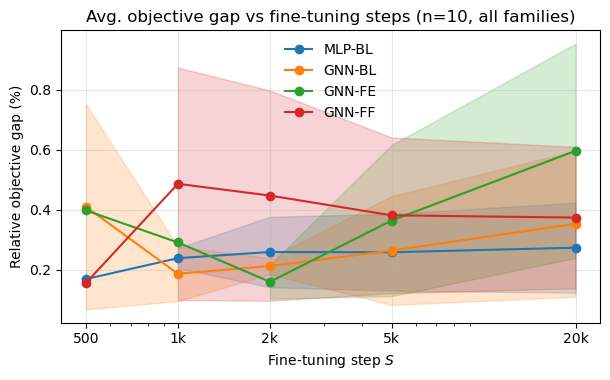

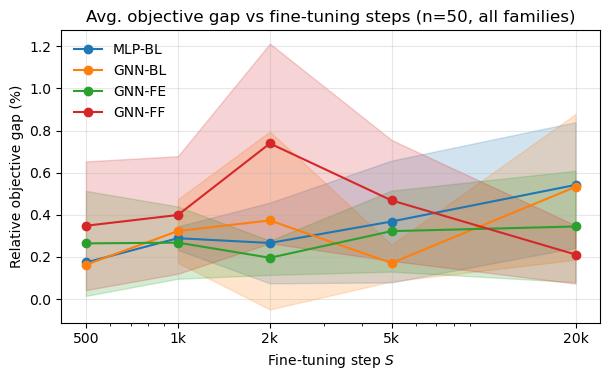

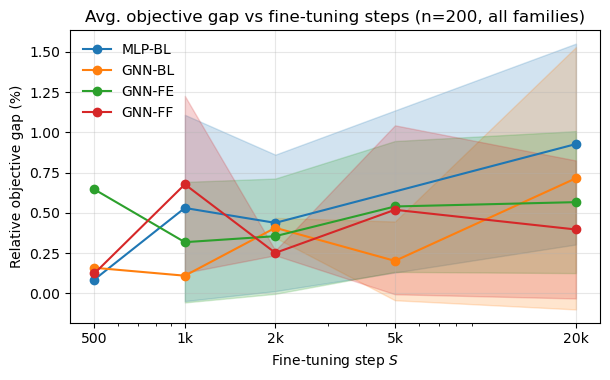

In [83]:
from matplotlib import pyplot as plt

def _scale_for_percent(values: pd.Series, df_gap_unit: str, metric_name: str):
    """
    Returns (scale_factor, y_label).
    df_gap_unit:
      - "auto": if 95th percentile <= 1.0 assume fraction -> multiply by 100
      - "fraction": assume values in [0,1] -> multiply by 100
      - "percent": assume already in % units -> multiply by 1
    """
    v = values.dropna()
    if v.empty:
        return 1.0, f"Relative {metric_name} (%)"

    if df_gap_unit == "fraction":
        return 100.0, f"Relative {metric_name} (%)"
    if df_gap_unit == "percent":
        return 1.0, f"Relative {metric_name} (%)"
    if df_gap_unit == "auto":
        q95 = v.quantile(0.95)
        return (100.0, f"Relative {metric_name} (%)") if q95 <= 1.0 else (1.0, f"Relative {metric_name} (%)")

    raise ValueError("df_gap_unit must be one of: 'auto', 'fraction', 'percent'")


def summarize_gap_over_runs(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/objective_gap",
    metric_name: str = "objective gap",
    step_subset: list[int] | None = STEPS,
    df_gap_unit: str = "auto",
) -> tuple[pd.DataFrame, str]:
    """
    Produces a tidy summary with columns:
      Method, step, mean, std, n_runs
    """
    d = df.copy()

    d = d[d["size"] == size]
    if dataset is not None:
        d = d[d["dataset"] == dataset]

    if step_subset is not None:
        d = d[d["step"].isin(step_subset)]

    if metric not in d.columns:
        raise KeyError(f"'{metric}' not in df.columns")

    d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])

    scale, y_label = _scale_for_percent(d[metric], df_gap_unit=df_gap_unit, metric_name=metric_name)

    per_run = (
        d.groupby(["Method", "run_dir", "step"], as_index=False)[metric]
         .mean()
    )
    per_run[metric] = per_run[metric] * scale

    summary = (
        per_run.groupby(["Method", "step"], as_index=False)[metric]
               .agg(mean="mean", std="std", n_runs="count")
    )
    summary["Method"] = pd.Categorical(
        summary["Method"],
        categories=METHOD_ORDER,
        ordered=True,
    )
    summary = summary.sort_values(["Method", "step"])

    return summary, y_label


def plot_gap_vs_step(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/objective_gap",
    metric_name: str = "objective gap",
    step_subset: list[int] | None = STEPS,
    df_gap_unit: str = "auto",
    show_band: bool = True,
    savepath: str | None = None,
):
    summary, y_label = summarize_gap_over_runs(
        df,
        size,
        dataset=dataset,
        metric=metric,
        metric_name=metric_name,
        step_subset=step_subset,
        df_gap_unit=df_gap_unit,
    )

    fig, ax = plt.subplots(figsize=(6.2, 3.9))

    for method in METHOD_ORDER:
        s = summary[summary["Method"] == method]
        if s.empty:
            continue

        (line,) = ax.plot(s["step"], s["mean"], marker="o", label=method)

        if show_band and "std" in s.columns:
            lo = (s["mean"] - s["std"]).to_numpy()
            hi = (s["mean"] + s["std"]).to_numpy()
            x = s["step"].to_numpy()
            ax.fill_between(x, lo, hi, alpha=0.2, color=line.get_color())

    ax.set_title(f"Avg. {metric_name} vs fine-tuning steps (n={size}, all families)")
    ax.set_xlabel("Fine-tuning step $S$")
    ax.set_ylabel(y_label)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

    if step_subset is not None:
        ax.set_xticks(step_subset)
        ax.set_xticklabels([f"{s//1000}k" if s >= 1000 else str(s) for s in step_subset])

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, ax


# -----------------------
# MAKE THE 3 PLOTS (averaged across all families)
# -----------------------

DATASET_FILTER = "all_families"

for n in [10, 50, 200]:
    plot_gap_vs_step(
        rows_avg_df,
        n,
        dataset=DATASET_FILTER,
        metric="valid/objective_gap",
        metric_name="objective gap",
        step_subset=STEPS,
        df_gap_unit="percent",
        show_band=True,
        savepath=f"objective_gap_vs_step_n{n}_all_families.pdf",
    )

plt.show()

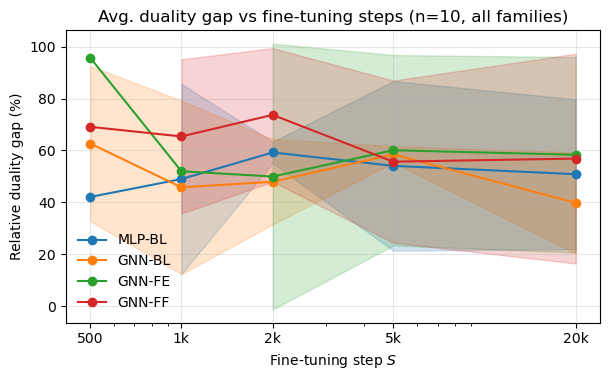

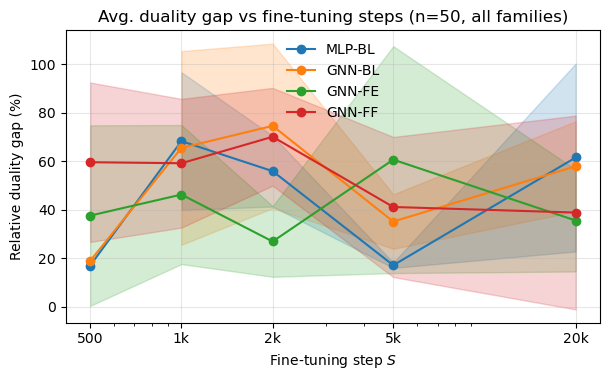

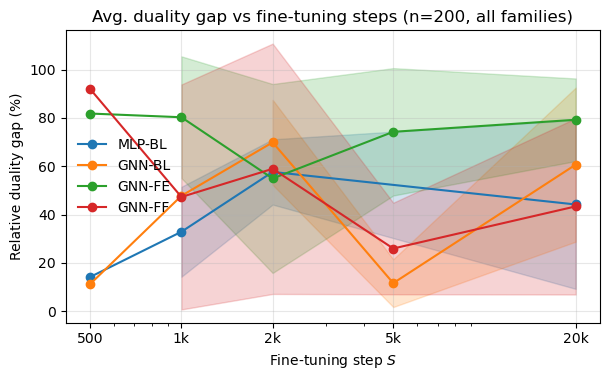

In [84]:

DATASET_FILTER = "all_families"

for n in [10, 50, 200]:
    plot_gap_vs_step(
        rows_avg_df,
        n,
        dataset=DATASET_FILTER,
        metric="valid/duality_gap",
        metric_name="duality gap",
        step_subset=STEPS,
        df_gap_unit="auto",
        show_band=True,
        savepath=f"duality_gap_vs_step_n{n}_all_families.pdf",
    )

plt.show()

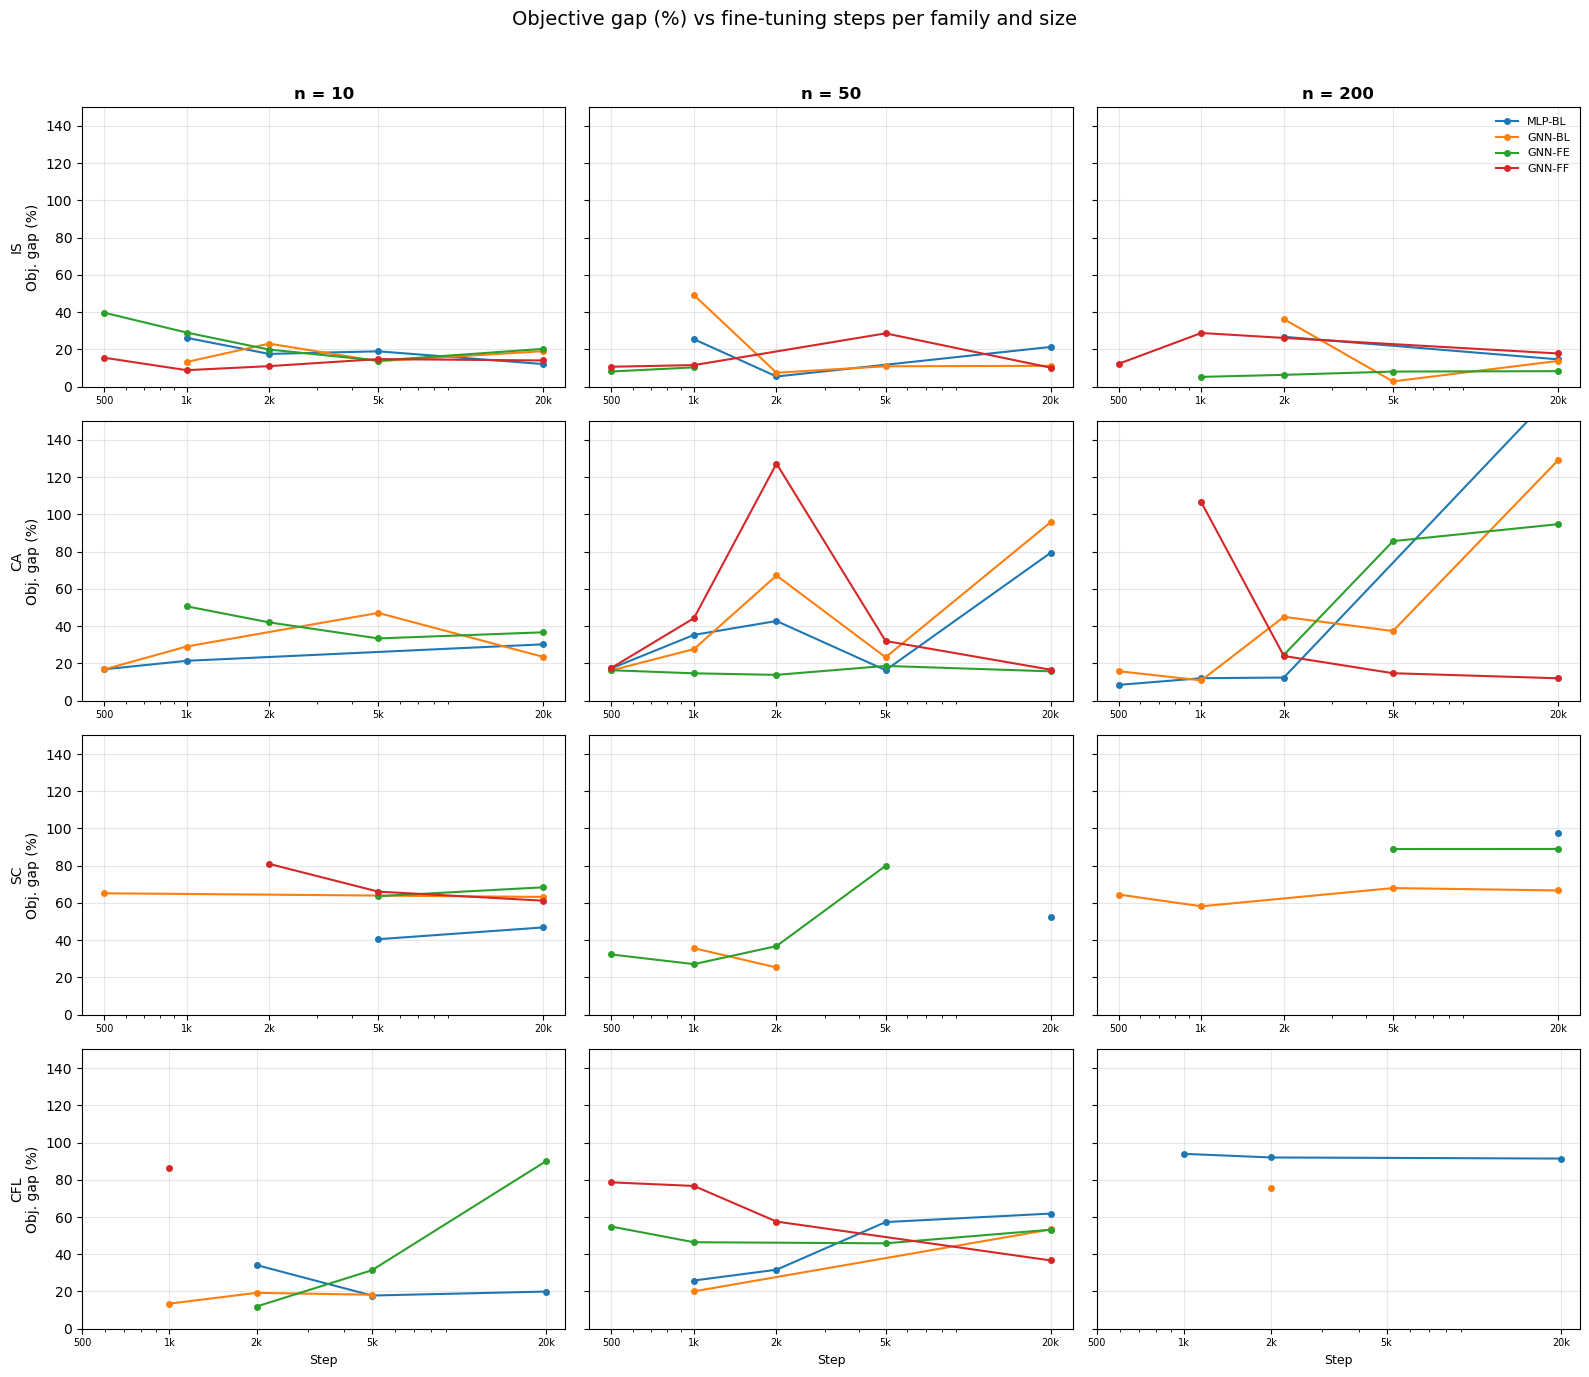

In [85]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharey="row")                                                                                                                                                                            
sizes_plot = [10, 50, 200]                                                                                           
metric = "valid/objective_gap"                                                                                       
                                                                                                                    
for row_idx, family in enumerate(FAMILIES):                                                                        
    for col_idx, size in enumerate(sizes_plot):
        ax = axes[row_idx, col_idx]                                                                                  

        d = rows_df[(rows_df["family"] == family) & (rows_df["size"] == size) & (rows_df["step"].isin(STEPS))].copy()
        d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])                                  
                                                                                                                    
        if d.empty:                                                                                                
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)                           
            continue                                                                                                 

        summary = (                                                                                                  
            d.groupby(["Method", "step"], as_index=False)[metric]                                                  
            .agg(mean="mean", std="std")
        )
                                                                                                                    
        for method in METHOD_ORDER:
            s = summary[summary["Method"] == method].sort_values("step")                                             
            if s.empty:                                                                                            
                continue
            line, = ax.plot(s["step"], s["mean"] * 100, marker="o", markersize=4, label=method)
            if s["std"].notna().any():                                                                               
                lo = (s["mean"] - s["std"]).clip(lower=0) * 100                                                      
                hi = (s["mean"] + s["std"]) * 100                                                                    
                ax.fill_between(s["step"].to_numpy(), lo.to_numpy(), hi.to_numpy(),                                  
                                alpha=0.15, color=line.get_color())                                                 
                                                                                                                    
        ax.set_xscale("log")        
        ax.set_ylim(0, 150)                                                                                          
        ax.set_xticks(STEPS)                                                                                         
        ax.set_xticklabels([f"{s//1000}k" if s >= 1000 else str(s) for s in STEPS], fontsize=7)                    
        ax.grid(True, alpha=0.3)                                                                                     

        if row_idx == 0:                                                                                             
            ax.set_title(f"n = {size}", fontsize=12, fontweight="bold")                                            
        if col_idx == 0:                                                                                             
            ax.set_ylabel(f"{family}\nObj. gap (%)", fontsize=10)                                                  
        if row_idx == 3:                                                                                             
            ax.set_xlabel("Step", fontsize=9)                                                                      
                                                                                                                    
axes[0, -1].legend(loc="upper right", fontsize=8, frameon=False)                                                   
fig.suptitle("Objective gap (%) vs fine-tuning steps per family and size", fontsize=14, y=0.98)                      
fig.tight_layout(rect=[0, 0, 1, 0.96])                                                                               
fig.savefig("objective_gap_grid_families_x_sizes.pdf", bbox_inches="tight")
plt.show()                                                                                                           
                

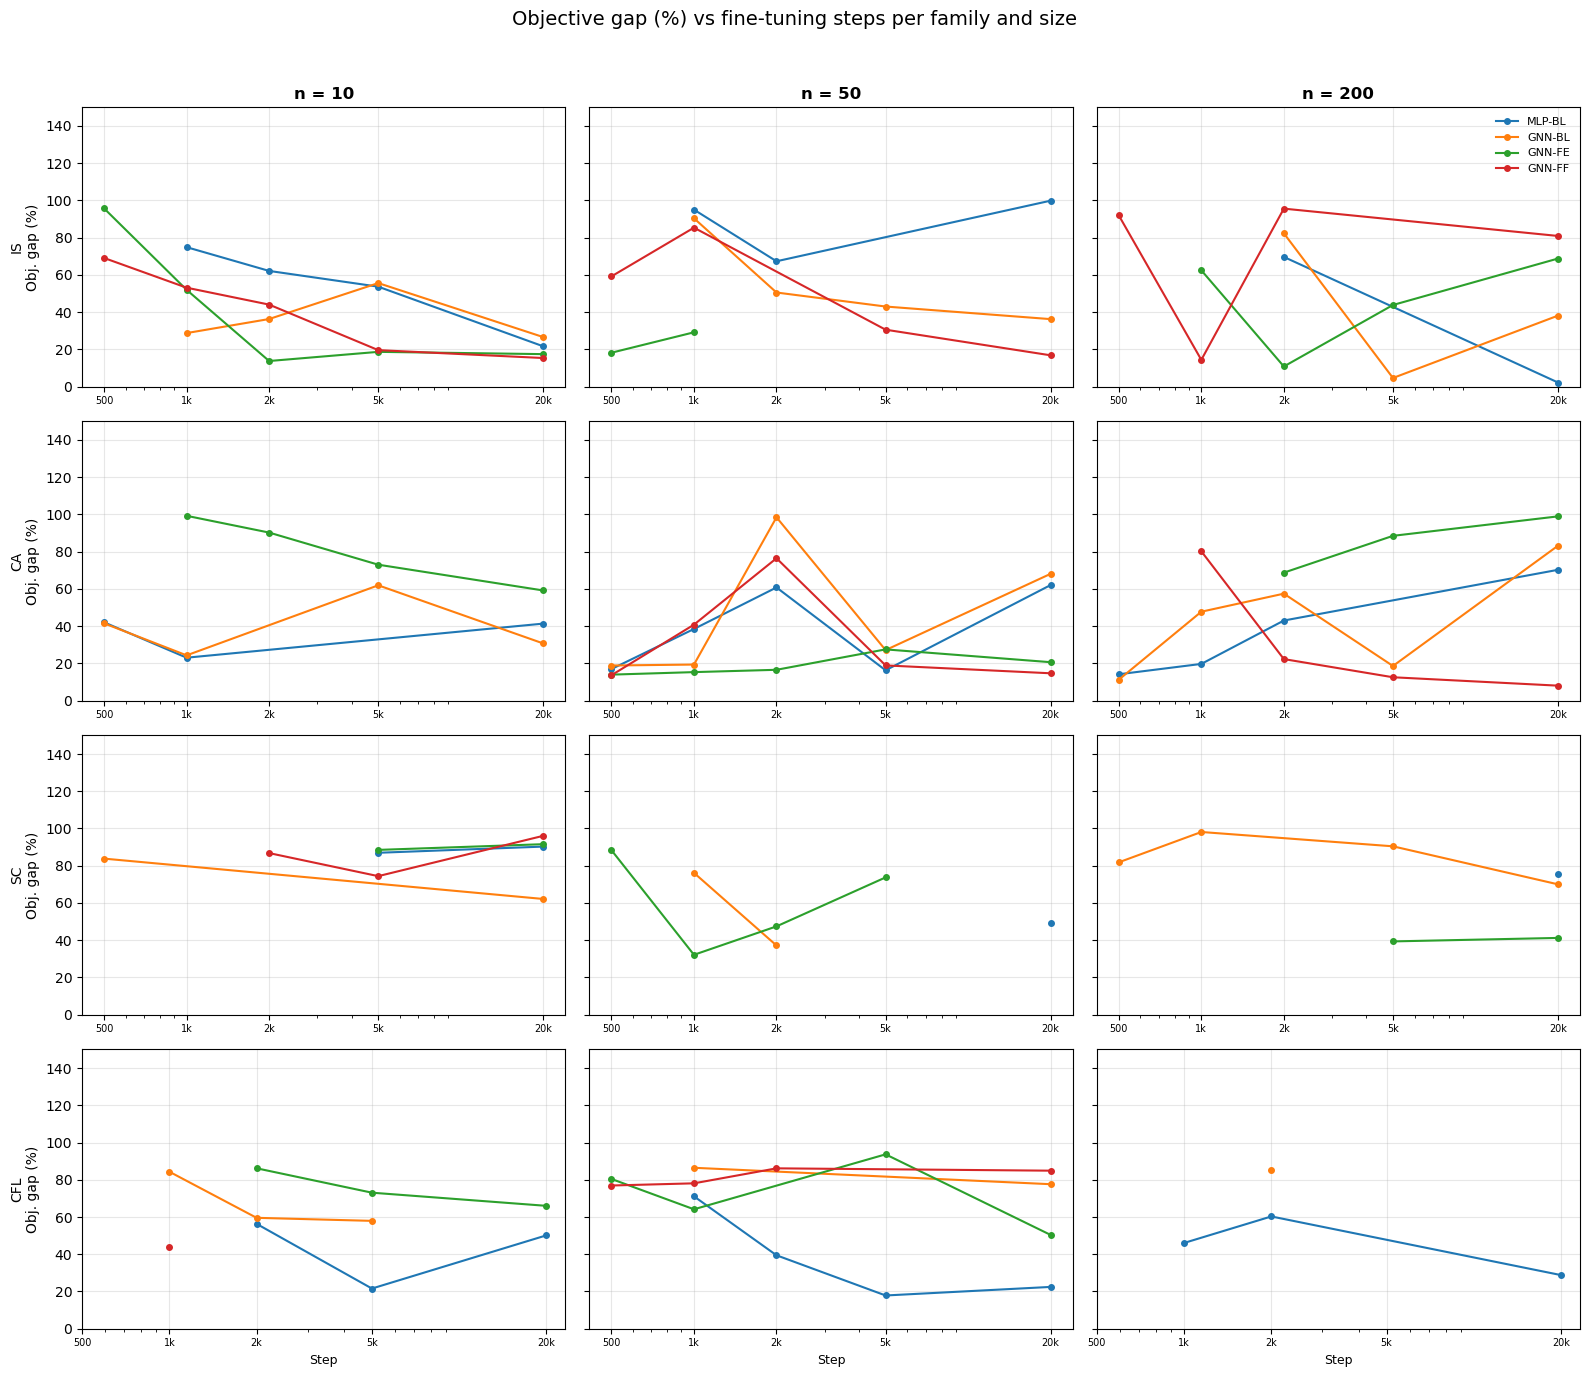

In [86]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharey="row")                                                                                                                                                                            
sizes_plot = [10, 50, 200]                                                                                           
metric = "valid/duality_gap"                                                                                       
                                                                                                                    
for row_idx, family in enumerate(FAMILIES):                                                                        
    for col_idx, size in enumerate(sizes_plot):
        ax = axes[row_idx, col_idx]                                                                                  

        d = rows_df[(rows_df["family"] == family) & (rows_df["size"] == size) & (rows_df["step"].isin(STEPS))].copy()
        d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])                                  
                                                                                                                    
        if d.empty:                                                                                                
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)                           
            continue                                                                                                 

        summary = (                                                                                                  
            d.groupby(["Method", "step"], as_index=False)[metric]                                                  
            .agg(mean="mean", std="std")
        )
                                                                                                                    
        for method in METHOD_ORDER:
            s = summary[summary["Method"] == method].sort_values("step")                                             
            if s.empty:                                                                                            
                continue
            line, = ax.plot(s["step"], s["mean"] * 100, marker="o", markersize=4, label=method)
            if s["std"].notna().any():                                                                               
                lo = (s["mean"] - s["std"]).clip(lower=0) * 100                                                      
                hi = (s["mean"] + s["std"]) * 100                                                                    
                ax.fill_between(s["step"].to_numpy(), lo.to_numpy(), hi.to_numpy(),                                  
                                alpha=0.15, color=line.get_color())                                                 
                                                                                                                    
        ax.set_xscale("log")        
        ax.set_ylim(0, 150)                                                                                          
        ax.set_xticks(STEPS)                                                                                         
        ax.set_xticklabels([f"{s//1000}k" if s >= 1000 else str(s) for s in STEPS], fontsize=7)                    
        ax.grid(True, alpha=0.3)                                                                                     

        if row_idx == 0:                                                                                             
            ax.set_title(f"n = {size}", fontsize=12, fontweight="bold")                                            
        if col_idx == 0:                                                                                             
            ax.set_ylabel(f"{family}\nObj. gap (%)", fontsize=10)                                                  
        if row_idx == 3:                                                                                             
            ax.set_xlabel("Step", fontsize=9)                                                                      
                                                                                                                    
axes[0, -1].legend(loc="upper right", fontsize=8, frameon=False)                                                   
fig.suptitle("Objective gap (%) vs fine-tuning steps per family and size", fontsize=14, y=0.98)                      
fig.tight_layout(rect=[0, 0, 1, 0.96])                                                                               
fig.savefig("objective_gap_grid_families_x_sizes.pdf", bbox_inches="tight")
plt.show()                                                                                                           
                

In [87]:
for size in [10, 50, 200]:                                                                                           
    print(f"\n{'='*80}")                                                                                             
    print(f"  Objective gap (%) — n = {size}")                                                                       
    print(f"{'='*80}")                                                                                             
    for family in FAMILIES:                                                                                          
        d = rows_df[(rows_df["family"] == family) & (rows_df["size"] == size) & (rows_df["step"].isin(STEPS))].copy()
        d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])
        pivot = d.pivot_table(index="Method", columns="step", values="valid/objective_gap", aggfunc="mean")          
        pivot = pivot.reindex(METHOD_ORDER).reindex(columns=STEPS) * 100
        pivot = pivot.map(lambda x: f"{x:.1f}" if pd.notna(x) else "--")                                             
        print(f"\n  {family}:")                                                                                      
        display(pivot)                                                                                               
                            


  Objective gap (%) — n = 10

  IS:


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,--,26.2,17.6,19.0,12.1
GNN-BL,--,13.2,23.1,13.7,19.0
GNN-FE,39.7,29.1,19.9,14.0,20.3
GNN-FF,15.5,8.8,11.0,14.8,14.1



  CA:


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,16.8,21.4,--,--,30.3
GNN-BL,16.8,29.1,--,47.1,23.5
GNN-FE,--,--,--,--,--
GNN-FF,--,50.7,42.0,33.4,36.7



  SC:


...

step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,8.5,12.1,12.4,--,167.4
GNN-BL,15.8,10.9,45.0,37.4,129.1
GNN-FE,--,--,24.6,85.7,94.8
GNN-FF,--,106.5,24.0,14.7,12.0



  SC:


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,--,--,--,--,97.5
GNN-BL,--,--,--,--,--
GNN-FE,64.5,58.2,--,68.0,66.7
GNN-FF,--,--,--,89.0,89.0



  CFL:


step,500,1000,2000,5000,20000
Method,,,,,
MLP-BL,--,93.9,92.0,--,91.4
GNN-BL,--,--,--,--,--
GNN-FE,--,--,75.5,--,--
GNN-FF,--,--,--,--,--
